# Análisis Exploratorio de Datos: ArXiv CS Subset (Top 10 Categorías)

Este notebook diagnostica el estado del subconjunto de artículos de arXiv con al menos una etiqueta del dominio `cs.*`. El análisis cuantifica tres problemas metodológicos clave antes de alimentar el pipeline de NLP:

1. **Fuga de Dominio**: artículos cuya categoría primaria no pertenece a `cs.*`.
2. **Inflación por Multi-etiquetado**: diferencia entre frecuencia bruta y documentos únicos.
3. **Solapamiento Lexical**: intersecciones entre categorías del Top 10, especialmente `cs.AI` y `cs.LG`.

## 0 : Instalación y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from itertools import combinations

# Configuracion global de visualizaciones
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


## 1 : Carga del Dataset

In [2]:
PARQUET_PATH = 'C:/Users/AaronMCC/Documents/arxiv_cs_dataset_exploration/dataset/arxiv_cs_top10.parquet'

# Columna que contiene las categorias como string separado por espacios
# Ejemplo: 'cs.LG cs.AI stat.ML'
CATEGORIES_COL = 'categories'

df = pd.read_parquet(PARQUET_PATH)

print(f'Shape del dataset: {df.shape}')
print(f'\nColumnas disponibles:\n{df.dtypes}\n')
print('Muestra de las primeras 3 filas:')
df.head(3)

Shape del dataset: (642077, 18)

Columnas disponibles:
id                object
submitter         object
authors           object
title             object
comments          object
journal-ref       object
doi               object
report-no         object
categories        object
license           object
abstract          object
versions          object
update_date       object
authors_parsed    object
year               int32
cat_list          object
cs_categories     object
cs_primary        object
dtype: object

Muestra de las primeras 3 filas:


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed,year,cat_list,cs_categories,cs_primary
1,0704.0046,Denes Petz,"I. Csiszar, F. Hiai and D. Petz",A limit relation for entropy and channel capac...,"LATEX file, 11 pages","J. Math. Phys. 48(2007), 092102.",10.1063/1.2779138,None,quant-ph cs.IT math.IT,None,"In a quantum mechanical model, Diosi, Feldma...","[{'created': 'Sun, 1 Apr 2007 16:37:36 GMT', '...",2009-11-13,"[[Csiszar, I., ], [Hiai, F., ], [Petz, D., ]]",2009,"[quant-ph, cs.IT, math.IT]",[cs.IT],cs.IT
4,0704.0062,Tom\'a\v{s} Vina\v{r},"Rastislav \v{S}r\'amek, Bro\v{n}a Brejov\'a, T...",On-line Viterbi Algorithm and Its Relationship...,None,Algorithms in Bioinformatics: 7th Internationa...,10.1007/978-3-540-74126-8_23,None,cs.DS,None,"In this paper, we introduce the on-line Vite...","[{'created': 'Sat, 31 Mar 2007 23:52:33 GMT', ...",2010-01-25,"[[Šrámek, Rastislav, ], [Brejová, Broňa, ], [V...",2010,[cs.DS],[cs.DS],cs.DS
6,0704.0098,Jack Raymond,"Jack Raymond, David Saad",Sparsely-spread CDMA - a statistical mechanics...,"23 pages, 5 figures, figure 1 amended since pu...",J. Phys. A: Math. Theor. 40 No 41 (12 October ...,10.1088/1751-8113/40/41/004,None,cs.IT math.IT,None,"Sparse Code Division Multiple Access (CDMA),...","[{'created': 'Sun, 1 Apr 2007 18:27:26 GMT', '...",2009-11-13,"[[Raymond, Jack, ], [Saad, David, ]]",2009,"[cs.IT, math.IT]",[cs.IT],cs.IT


## 2 : Ingeniería de Columnas Base

In [3]:
# Convertir el campo de categorias de string a lista
df['cat_list'] = df[CATEGORIES_COL].str.split()

# Categoria Primaria: primera etiqueta en la lista de metadatos
df['primary_category'] = df['cat_list'].str[0]

# Prefijo del dominio primario (ej. 'cs', 'math', 'eess', 'stat')
df['primary_prefix'] = df['primary_category'].str.split('.').str[0]

# Categorias secundarias: resto de la lista (puede ser lista vacia)
df['secondary_categories'] = df['cat_list'].apply(lambda x: x[1:] if len(x) > 1 else [])

# Numero total de etiquetas por articulo
df['n_categories'] = df['cat_list'].apply(len)

# Flag: el articulo es mono-etiquetado (pureza maxima)
df['is_single_label'] = df['n_categories'] == 1

print('Columnas generadas: cat_list, primary_category, primary_prefix,')
print('                    secondary_categories, n_categories, is_single_label')
print(f'\nDistribucion de numero de etiquetas por articulo:')
print(df['n_categories'].value_counts().sort_index().head(10))
print(f'\nMuestra con las nuevas columnas:')
df[['primary_category', 'primary_prefix', 'n_categories', 'is_single_label', 'cat_list']].head(5)

Columnas generadas: cat_list, primary_category, primary_prefix,
                    secondary_categories, n_categories, is_single_label

Distribucion de numero de etiquetas por articulo:
n_categories
1     217849
2     242763
3     125518
4      39222
5      12687
6       3302
7        656
8         69
9          6
10         3
Name: count, dtype: int64

Muestra con las nuevas columnas:


,primary_category,primary_prefix,n_categories,is_single_label,cat_list
1,quant-ph,quant-ph,3,False,"[quant-ph, cs.IT, math.IT]"
4,cs.DS,cs,1,True,[cs.DS]
6,cs.IT,cs,2,False,"[cs.IT, math.IT]"
9,cs.IT,cs,2,False,"[cs.IT, math.IT]"
12,cs.IT,cs,3,False,"[cs.IT, cs.CC, math.IT]"


## 3 : Identificación del Top 10 de Categorías

In [4]:
# Conteo de frecuencia bruta: cada aparicion de una etiqueta cuenta,
# independientemente de si es primaria o secundaria.
# Un articulo con ['cs.LG', 'cs.AI'] suma 1 a cs.LG y 1 a cs.AI.
all_tags = df['cat_list'].explode()
global_freq = all_tags.value_counts()

# Top 10 categorias por frecuencia global
TOP_N = 10
top10 = global_freq.head(TOP_N).index.tolist()

print(f'Top {TOP_N} categorias por frecuencia bruta (conteo multi-etiqueta):')
freq_df = global_freq.head(TOP_N).reset_index()
freq_df.columns = ['Categoria', 'Frecuencia Bruta']
print(freq_df.to_string(index=False))

print(f'\nNota: la frecuencia bruta SUPERA el numero de articulos unicos')
print(f'porque un articulo con N etiquetas del Top 10 se cuenta N veces.')

Top 10 categorias por frecuencia bruta (conteo multi-etiqueta):
Categoria  Frecuencia Bruta
    cs.LG            233426
    cs.CV            180144
    cs.AI            142311
    cs.CL             96696
  stat.ML             64603
  math.IT             50902
    cs.IT             50902
    cs.RO             48442
    cs.CR             41963
    cs.SY             39472

Nota: la frecuencia bruta SUPERA el numero de articulos unicos
porque un articulo con N etiquetas del Top 10 se cuenta N veces.


## 4 : Tabla de Distribución Principal

In [5]:
# Para cada categoria del Top 10, calcular metricas de distribucion.

rows = []

for cat in top10:
    # Mascara: articulos que contienen esta categoria en cualquier posicion
    mask_any = df['cat_list'].apply(lambda x: cat in x)

    # Mascara: articulos donde esta categoria es la primaria
    mask_primary = df['primary_category'] == cat

    # Subsets
    sub_any = df[mask_any]
    n_total = mask_any.sum()
    n_primary = mask_primary.sum()
    n_secondary = n_total - n_primary

    # Pureza estricta: articulos con SOLO esta etiqueta (sin ninguna otra)
    n_pure_strict = int((mask_any & df['is_single_label']).sum())

    # Pureza de dominio CS: articulos con esta etiqueta cuya primaria es cs.*
    n_pure_cs = int((mask_any & (df['primary_prefix'] == 'cs')).sum())

    rows.append({
        'Categoria': cat,
        'Volumen Total': n_total,
        'Como Primaria': n_primary,
        'Como Secundaria': n_secondary,
        'Pureza Estricta (mono-label)': n_pure_strict,
        'Pct Pureza Estricta': round(100 * n_pure_strict / n_total, 1) if n_total > 0 else 0,
        'Pureza Dominio CS': n_pure_cs,
        'Pct Pureza CS': round(100 * n_pure_cs / n_total, 1) if n_total > 0 else 0,
    })

dist_df = pd.DataFrame(rows).sort_values('Volumen Total', ascending=False).reset_index(drop=True)

print('Tabla de Distribucion Principal — Top 10 Categorias\n')
print(dist_df.to_string(index=False))

Tabla de Distribucion Principal — Top 10 Categorias

Categoria  Volumen Total  Como Primaria  Como Secundaria  Pureza Estricta (mono-label)  Pct Pureza Estricta  Pureza Dominio CS  Pct Pureza CS
    cs.LG         233426         127899           105527                         30364                13.00             185617          79.50
    cs.CV         180144         142953            37191                         85979                47.70             162591          90.30
    cs.AI         142311          35511           106800                         16912                11.90             131523          92.40
    cs.CL          96696          77738            18958                         37233                38.50              93255          96.40
  stat.ML          64603          17215            47388                             0                 0.00              41508          64.30
  math.IT          50902              0            50902                             0         

## 5 : Tabla de Fuga de Dominio

In [6]:
# Articulos que contienen al menos una etiqueta del Top 10
mask_in_top10 = df['cat_list'].apply(lambda x: bool(set(x) & set(top10)))
df_top10 = df[mask_in_top10].copy()

print(f'Articulos con al menos una etiqueta del Top 10: {len(df_top10):,}')

# Fuga: categoria primaria NO empieza con cs.
mask_leakage = df_top10['primary_prefix'] != 'cs'
df_leakage = df_top10[mask_leakage]

n_leakage = len(df_leakage)
pct_leakage = 100 * n_leakage / len(df_top10)

print(f'Articulos con fuga de dominio (primaria fuera de cs.*): {n_leakage:,} ({pct_leakage:.2f}%)\n')

# Tabla 5a: Prefijos foraneos mas comunes en posicion primaria
leakage_prefix = df_leakage['primary_prefix'].value_counts().reset_index()
leakage_prefix.columns = ['Prefijo Foraneo', 'Conteo']
leakage_prefix['Pct sobre Fuga'] = (100 * leakage_prefix['Conteo'] / n_leakage).round(1)

print('Tabla 5a — Prefijos Foraneos en Posicion Primaria (Top 15):')
print(leakage_prefix.head(15).to_string(index=False))

print()

# Tabla 5b: Categorias primarias foraneas individuales mas frecuentes
leakage_cat = df_leakage['primary_category'].value_counts().reset_index()
leakage_cat.columns = ['Categoria Primaria Foranea', 'Conteo']
leakage_cat['Pct sobre Fuga'] = (100 * leakage_cat['Conteo'] / n_leakage).round(1)

print('Tabla 5b — Categorias Primarias Foraneas Individuales (Top 15):')
print(leakage_cat.head(15).to_string(index=False))

Articulos con al menos una etiqueta del Top 10: 598,475
Articulos con fuga de dominio (primaria fuera de cs.*): 99,610 (16.64%)

Tabla 5a — Prefijos Foraneos en Posicion Primaria (Top 15):
Prefijo Foraneo  Conteo  Pct sobre Fuga
           eess   44896           45.10
           stat   19622           19.70
           math   13494           13.50
        physics    5006            5.00
       quant-ph    5000            5.00
          q-bio    4575            4.60
       cond-mat    1709            1.70
       astro-ph    1419            1.40
          q-fin    1368            1.40
         cmp-lg     894            0.90
           econ     552            0.60
           nlin     305            0.30
         hep-ph     212            0.20
         hep-ex     139            0.10
        math-ph     127            0.10

Tabla 5b — Categorias Primarias Foraneas Individuales (Top 15):
Categoria Primaria Foranea  Conteo  Pct sobre Fuga
                   eess.SY   19428           19.50
    

## 6 : Visualización 1: Heatmap de Co-ocurrencia

C:\Users\AaronMCC\AppData\Local\Temp\ipykernel_29000\1787593501.py:24: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_labels = cooc_ordered.applymap(lambda v: f'{v:,}')


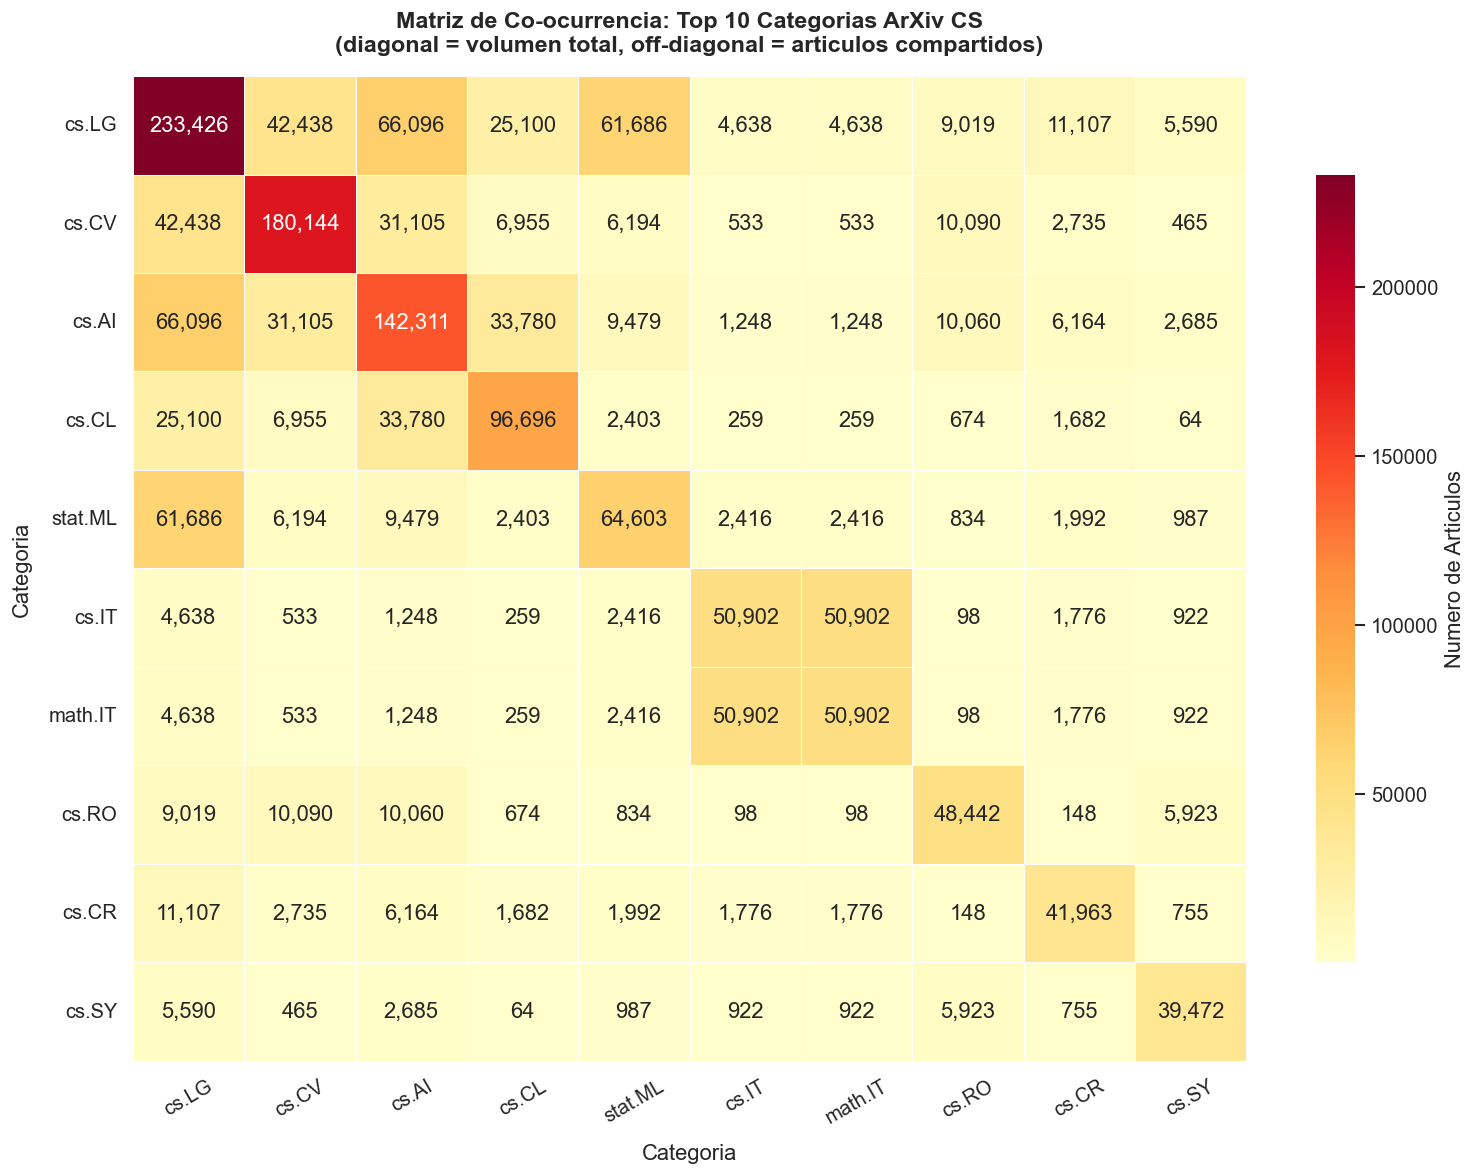

Figura guardada como coocurrencia_top10.png


In [7]:
# Construir matriz de co-ocurrencia 10x10
# La celda [i, j] = numero de articulos que contienen AMBAS categorias i y j.
# La diagonal [i, i] = Volumen Total de la categoria i.

cooc_matrix = pd.DataFrame(0, index=top10, columns=top10, dtype=int)

for _, row in df.iterrows():
    cats_in_top10 = [c for c in row['cat_list'] if c in top10]
    if len(cats_in_top10) == 0:
        continue
    # Diagonal
    for c in cats_in_top10:
        cooc_matrix.loc[c, c] += 1
    # Off-diagonal: pares no ordenados
    for c1, c2 in combinations(set(cats_in_top10), 2):
        cooc_matrix.loc[c1, c2] += 1
        cooc_matrix.loc[c2, c1] += 1

# Ordenar las categorias por volumen total (diagonal) de mayor a menor
order = cooc_matrix.values.diagonal().argsort()[::-1]
cooc_ordered = cooc_matrix.iloc[order, order]

# Para la anotacion, usar miles con punto si el numero es grande
annot_labels = cooc_ordered.applymap(lambda v: f'{v:,}')

fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    cooc_ordered,
    annot=annot_labels,
    fmt='',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Numero de Articulos', 'shrink': 0.8}
)

ax.set_title(
    'Matriz de Co-ocurrencia: Top 10 Categorias ArXiv CS\n'
    '(diagonal = volumen total, off-diagonal = articulos compartidos)',
    pad=15
)
ax.set_xlabel('Categoria', labelpad=10)
ax.set_ylabel('Categoria', labelpad=10)
ax.tick_params(axis='x', rotation=30)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('coocurrencia_top10.png', bbox_inches='tight')
plt.show()
print('Figura guardada como coocurrencia_top10.png')

## 7 : Visualización 2: Barras Apiladas (Puros vs Multi-etiquetados)

Datos para grafico de barras apiladas:
Categoria  Puros (Top 10)  Pct Puros  Multi-etiquetados (Top 10)  Pct Multi  Total
    cs.LG           64212      27.50                      169214      72.50 233426
    cs.CV          107536      59.70                       72608      40.30 180144
    cs.AI           27244      19.10                      115067      80.90 142311
    cs.CL           45665      47.20                       51031      52.80  96696
  stat.ML             389       0.60                       64214      99.40  64603
  math.IT               0       0.00                       50902     100.00  50902
    cs.IT               0       0.00                       50902     100.00  50902
    cs.RO           22728      46.90                       25714      53.10  48442
    cs.CR           23753      56.60                       18210      43.40  41963
    cs.SY           26501      67.10                       12971      32.90  39472


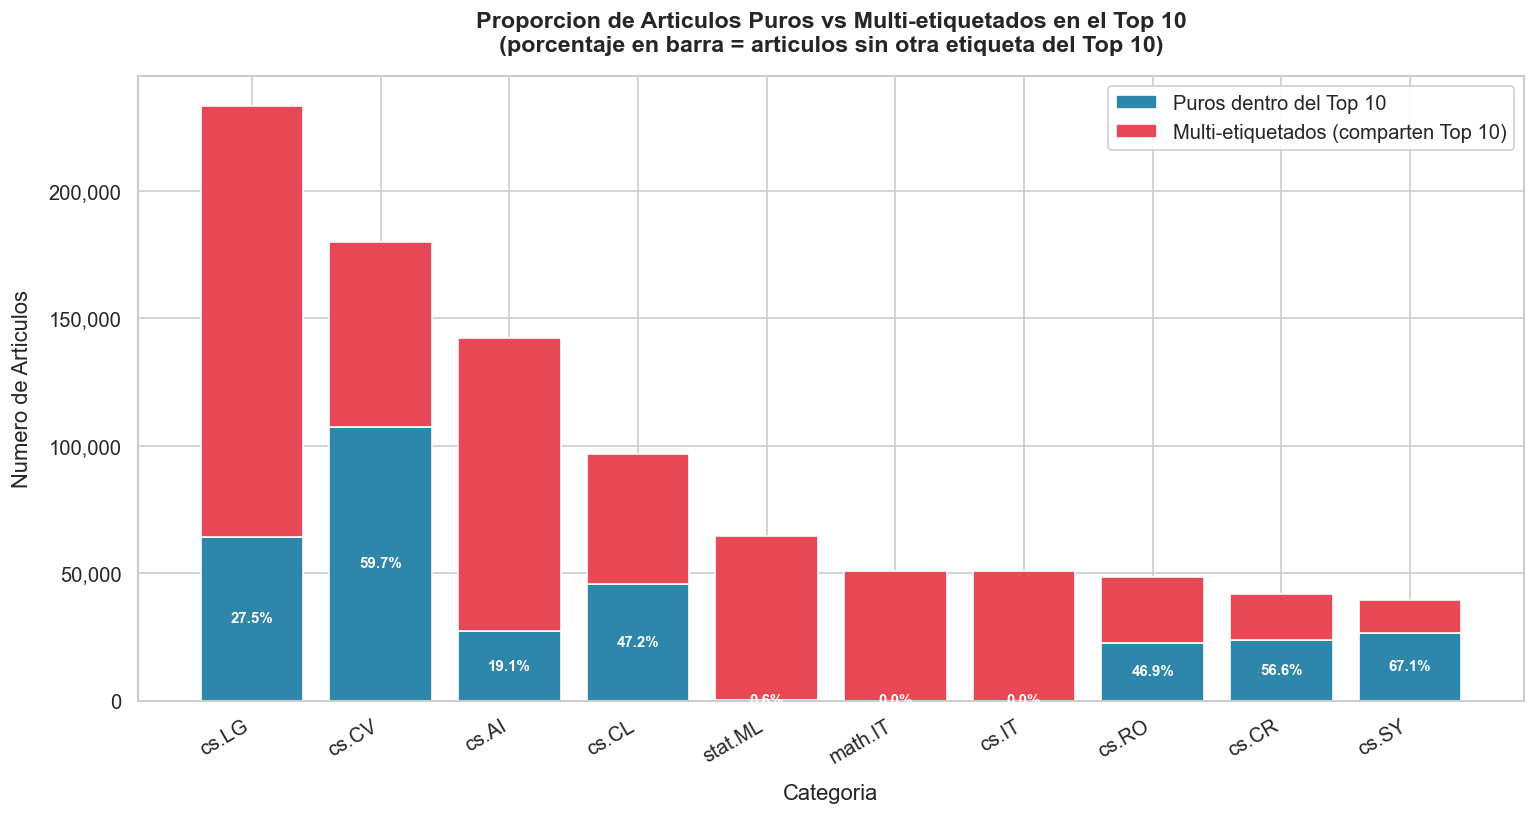

Figura guardada como barras_apiladas_top10.png


In [8]:
# Para cada categoria del Top 10, calcular:
# - Articulos puros respecto al Top 10: tienen esa etiqueta y NINGUNA OTRA del Top 10
# - Articulos multi-etiquetados: tienen esa etiqueta y al menos otra del Top 10

top10_set = set(top10)

stacked_rows = []
for cat in top10:
    mask_any = df['cat_list'].apply(lambda x: cat in x)
    sub = df[mask_any]

    # Cuantas etiquetas del Top 10 tiene este articulo (incluyendo la propia)
    n_top10_tags = sub['cat_list'].apply(lambda x: len(set(x) & top10_set))

    n_pure = int((n_top10_tags == 1).sum())       # solo esta etiqueta del Top 10
    n_multi = int((n_top10_tags > 1).sum())        # esta + al menos otra del Top 10

    stacked_rows.append({
        'Categoria': cat,
        'Puros (Top 10)': n_pure,
        'Multi-etiquetados (Top 10)': n_multi,
        'Total': n_pure + n_multi
    })

stacked_df = pd.DataFrame(stacked_rows).sort_values('Total', ascending=False).reset_index(drop=True)

stacked_df['Pct Puros'] = (100 * stacked_df['Puros (Top 10)'] / stacked_df['Total']).round(1)
stacked_df['Pct Multi'] = (100 * stacked_df['Multi-etiquetados (Top 10)'] / stacked_df['Total']).round(1)

print('Datos para grafico de barras apiladas:')
print(stacked_df[['Categoria', 'Puros (Top 10)', 'Pct Puros', 'Multi-etiquetados (Top 10)', 'Pct Multi', 'Total']].to_string(index=False))

# Grafico
fig, ax = plt.subplots(figsize=(13, 7))

x = range(len(stacked_df))
bars_pure = ax.bar(
    x,
    stacked_df['Puros (Top 10)'],
    label='Puros dentro del Top 10',
    color='#2E86AB',
    edgecolor='white'
)
bars_multi = ax.bar(
    x,
    stacked_df['Multi-etiquetados (Top 10)'],
    bottom=stacked_df['Puros (Top 10)'],
    label='Multi-etiquetados (comparten Top 10)',
    color='#E84855',
    edgecolor='white'
)

# Anotacion de porcentaje sobre el segmento puro
for i, row in stacked_df.iterrows():
    ax.text(
        i,
        row['Puros (Top 10)'] / 2,
        f"{row['Pct Puros']}%",
        ha='center', va='center',
        color='white', fontsize=9, fontweight='bold'
    )

ax.set_xticks(list(x))
ax.set_xticklabels(stacked_df['Categoria'], rotation=30, ha='right')
ax.set_xlabel('Categoria', labelpad=10)
ax.set_ylabel('Numero de Articulos', labelpad=10)
ax.set_title(
    'Proporcion de Articulos Puros vs Multi-etiquetados en el Top 10\n'
    '(porcentaje en barra = articulos sin otra etiqueta del Top 10)',
    pad=15
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda val, _: f'{int(val):,}'))
ax.legend(loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('barras_apiladas_top10.png', bbox_inches='tight')
plt.show()
print('Figura guardada como barras_apiladas_top10.png')

## 7b : Grafico de Red de Co-ocurrencia

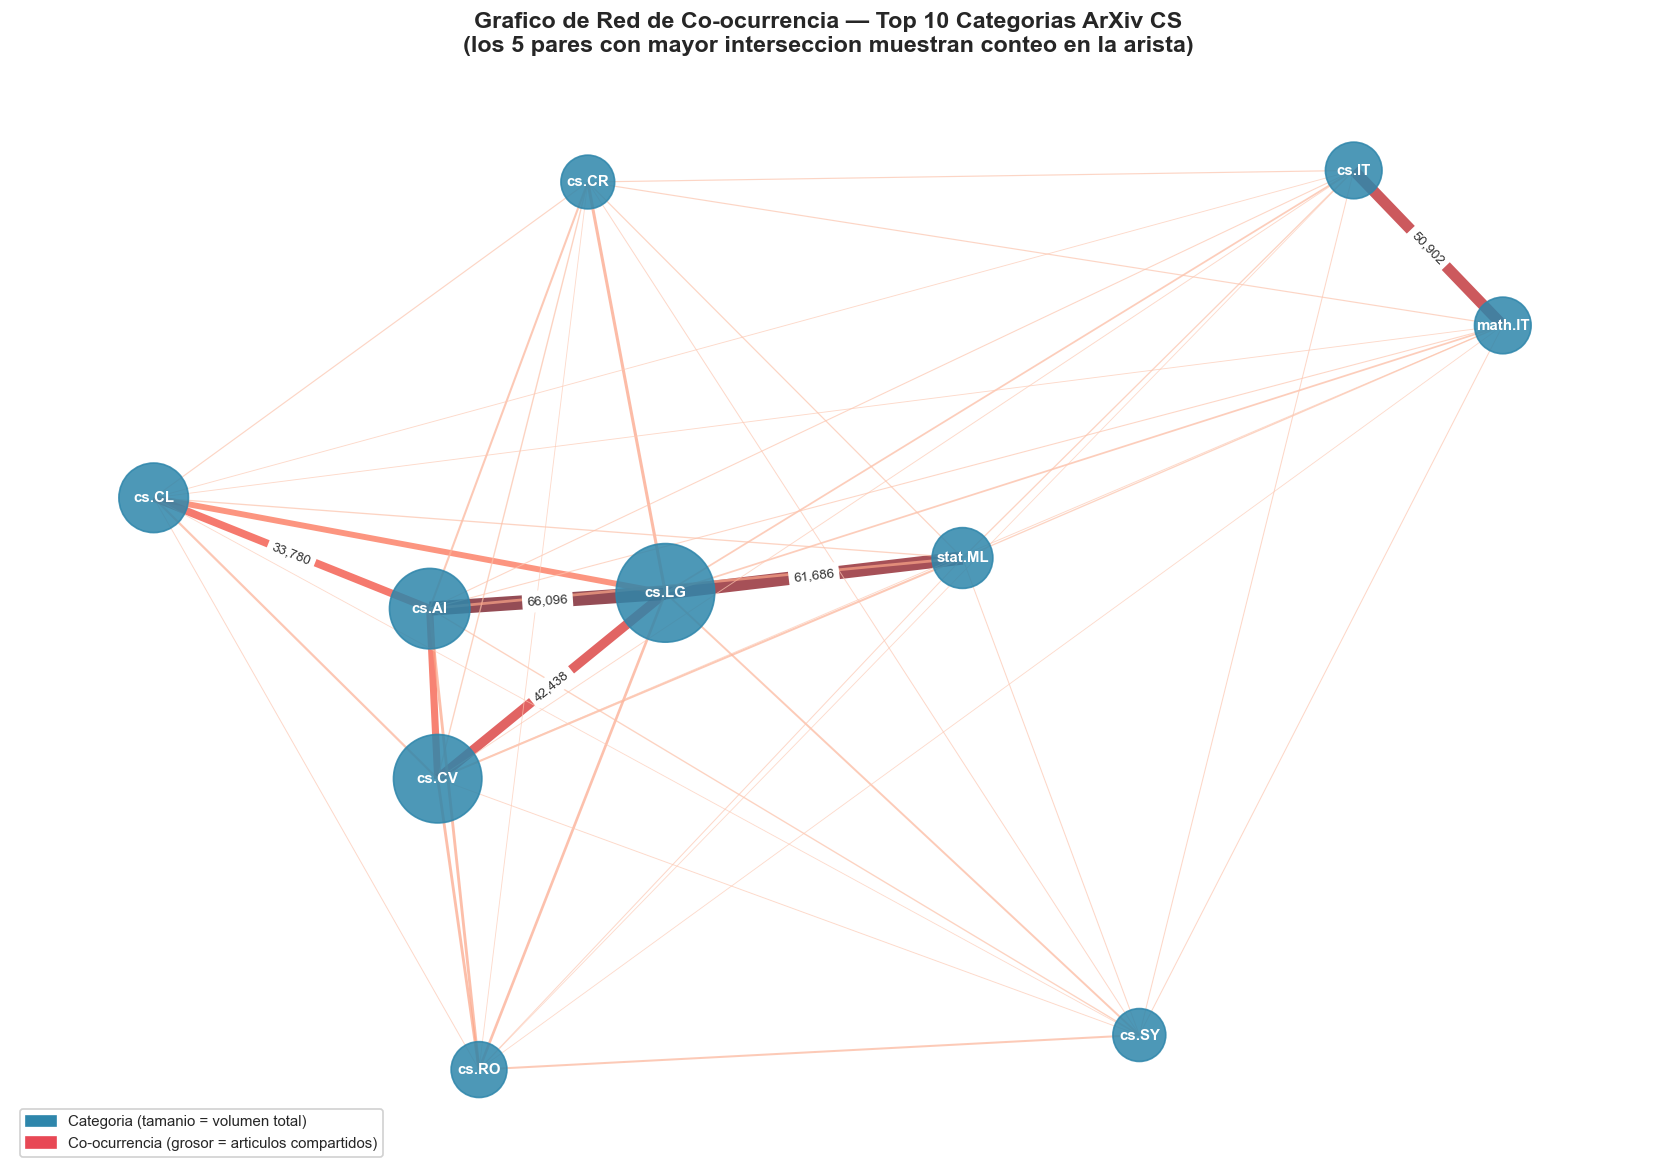

Figura guardada como red_coocurrencia_top10.png


In [9]:
# Instalacion requerida (ejecutar una sola vez)
!pip install -q networkx

import networkx as nx
import matplotlib.patches as mpatches

# Construir el grafo a partir de la matriz de co-ocurrencia ya calculada.
# Los nodos son las 10 categorias y las aristas representan articulos compartidos.
# Solo se incluyen aristas con al menos 1 articulo en comun (off-diagonal > 0).

G = nx.Graph()
G.add_nodes_from(top10)

for i, cat1 in enumerate(cooc_ordered.index):
    for j, cat2 in enumerate(cooc_ordered.columns):
        if i >= j:
            continue
        weight = int(cooc_ordered.loc[cat1, cat2])
        if weight > 0:
            G.add_edge(cat1, cat2, weight=weight)

# Tamanio de nodos proporcional al volumen total (diagonal de la matriz)
node_sizes = [cooc_ordered.loc[cat, cat] for cat in G.nodes()]
max_size = max(node_sizes)
node_sizes_scaled = [3000 * (s / max_size) + 500 for s in node_sizes]

# Grosor de aristas proporcional al peso (numero de articulos compartidos)
edges = G.edges(data=True)
weights = [d['weight'] for _, _, d in edges]
max_weight = max(weights) if weights else 1
edge_widths = [0.5 + 8 * (w / max_weight) for w in weights]

# Color de aristas segun intensidad de solapamiento
edge_colors = [plt.cm.Reds(0.2 + 0.8 * (w / max_weight)) for w in weights]

# Layout: spring con semilla fija para reproducibilidad
pos = nx.spring_layout(G, weight='weight', seed=42, k=2.5)

fig, ax = plt.subplots(figsize=(14, 10))

nx.draw_networkx_nodes(
    G, pos,
    node_size=node_sizes_scaled,
    node_color='#2E86AB',
    alpha=0.85,
    ax=ax
)

nx.draw_networkx_labels(
    G, pos,
    font_size=9,
    font_color='white',
    font_weight='bold',
    ax=ax
)

nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.7,
    ax=ax
)

# Etiquetas de peso en las aristas mas relevantes (top 5 por peso)
top_edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:5]
edge_labels = {(u, v): f'{d["weight"]:,}' for u, v, d in top_edges}
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=8,
    font_color='#333333',
    ax=ax
)

# Leyenda
patch_node = mpatches.Patch(color='#2E86AB', label='Categoria (tamanio = volumen total)')
patch_edge = mpatches.Patch(color='#E84855', label='Co-ocurrencia (grosor = articulos compartidos)')
ax.legend(handles=[patch_node, patch_edge], loc='lower left', framealpha=0.9, fontsize=9)

ax.set_title(
    'Grafico de Red de Co-ocurrencia — Top 10 Categorias ArXiv CS\n'
    '(los 5 pares con mayor interseccion muestran conteo en la arista)',
    pad=15
)
ax.axis('off')

plt.tight_layout()
plt.savefig('red_coocurrencia_top10.png', bbox_inches='tight')
plt.show()
print('Figura guardada como red_coocurrencia_top10.png')

## 7c : UpSet Plot (Top 30 Combinaciones)


Combinaciones unicas encontradas (total): 225
Mostrando las 30 mas frecuentes.



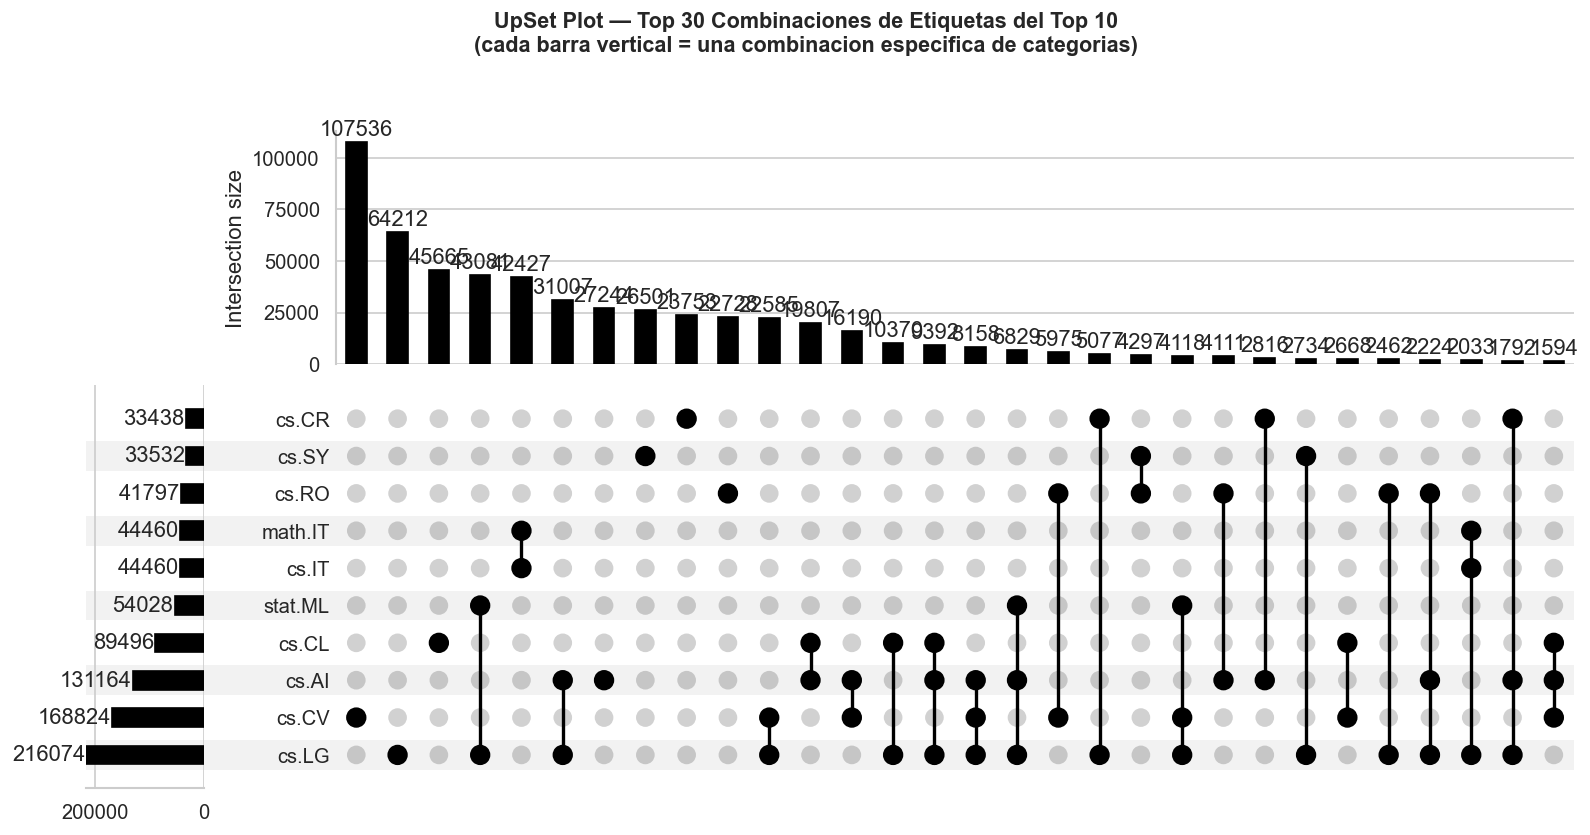

Figura guardada como upset_plot_top10.png
Ajustar TOP_COMBINATIONS para ver mas o menos combinaciones.


In [11]:
from upsetplot import UpSet
import warnings
warnings.filterwarnings('ignore')

TOP_COMBINATIONS = 30

top10_set = set(top10)

# Paso 1: contar combinaciones ANTES de construir el objeto UpSet.
# Esto opera sobre una Series simple, sin MultiIndex, sin explosion de memoria.
combo_series = (
    df['cat_list']
    .apply(lambda x: tuple(sorted(set(x) & top10_set)))
    .loc[lambda s: s.apply(len) > 0]
    .value_counts()
    .head(TOP_COMBINATIONS)
)

print(f'Combinaciones unicas encontradas (total): '
      f'{df["cat_list"].apply(lambda x: tuple(sorted(set(x) & top10_set))).value_counts().shape[0]}')
print(f'Mostrando las {TOP_COMBINATIONS} mas frecuentes.\n')

# Paso 2: construir el MultiIndex manualmente solo sobre las combinaciones filtradas.
# Esto evita que upsetplot intente crear el indice completo de 2^10 entradas.
categorias_presentes = sorted(set(cat for combo in combo_series.index for cat in combo))

index_tuples = [
    tuple(cat in combo for cat in categorias_presentes)
    for combo in combo_series.index
]

multi_index = pd.MultiIndex.from_tuples(
    index_tuples,
    names=categorias_presentes
)

upset_data_filtered = pd.Series(
    combo_series.values,
    index=multi_index,
    name='Frecuencia'
)

# Paso 3: grafico
fig = plt.figure(figsize=(18, 8))

upset = UpSet(
    upset_data_filtered,
    subset_size='auto',
    show_counts=True,
    sort_by='cardinality',
    sort_categories_by='cardinality',
    totals_plot_elements=3
)

upset.plot(fig)

fig.suptitle(
    f'UpSet Plot — Top {TOP_COMBINATIONS} Combinaciones de Etiquetas del Top 10\n'
    f'(cada barra vertical = una combinacion especifica de categorias)',
    y=1.02,
    fontsize=13,
    fontweight='bold'
)

plt.savefig('upset_plot_top10.png', bbox_inches='tight')
plt.show()
print(f'Figura guardada como upset_plot_top10.png')
print(f'Ajustar TOP_COMBINATIONS para ver mas o menos combinaciones.')


## 7d : Treemap de Frecuencias y Co-ocurrencias

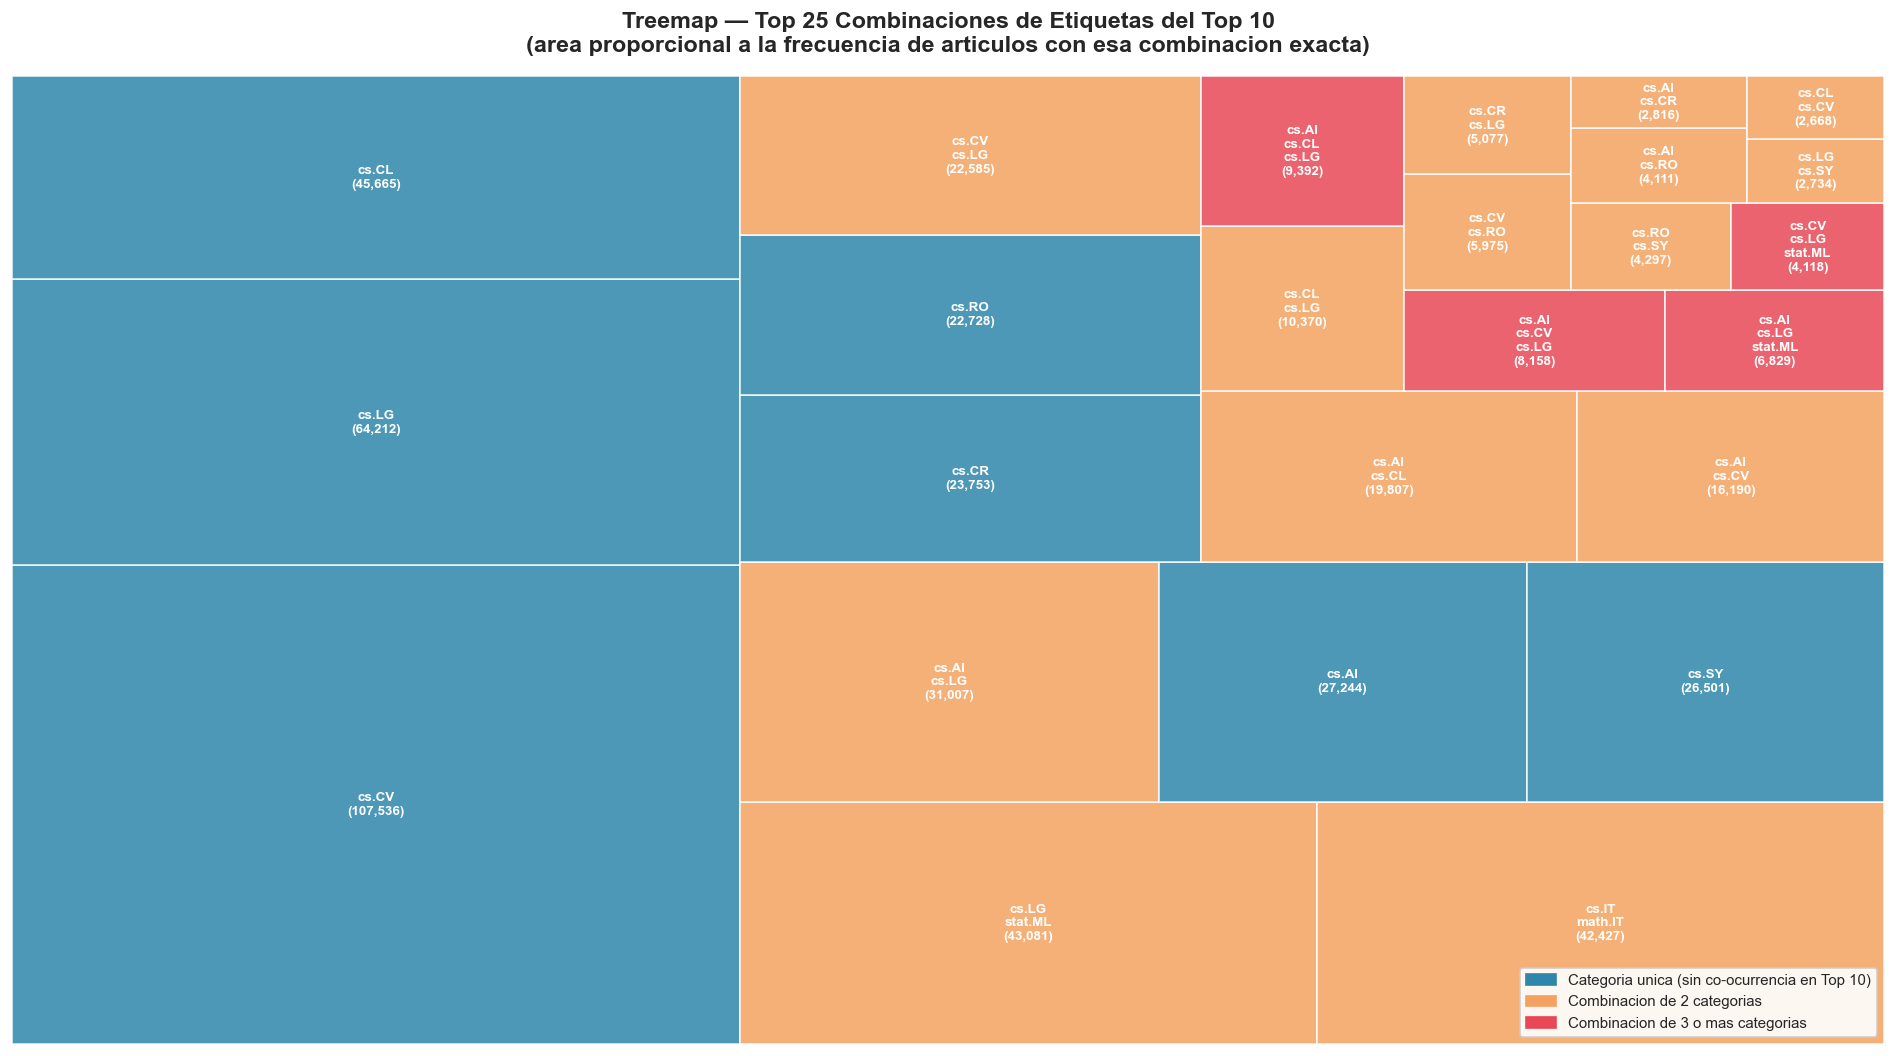

Figura guardada como treemap_top10.png
Ajustar TOP_TREEMAP para mostrar mas o menos combinaciones.


In [12]:
# Instalacion requerida (ejecutar una sola vez)
!pip install -q squarify

import squarify

# Parametro ajustable: cuantas combinaciones mostrar en el treemap
TOP_TREEMAP = 25

# Construir tabla de combinaciones con su frecuencia
top10_set = set(top10)

combo_counts = (
    df['cat_list']
    .apply(lambda x: tuple(sorted(set(x) & top10_set)))
    .loc[lambda s: s.apply(len) > 0]
    .value_counts()
    .head(TOP_TREEMAP)
    .reset_index()
)
combo_counts.columns = ['Combinacion', 'Frecuencia']

# Etiqueta legible para cada rectangulo
combo_counts['Label'] = combo_counts.apply(
    lambda row: '\n'.join(row['Combinacion']) + f'\n({row["Frecuencia"]:,})',
    axis=1
)

# Color: categorias solitarias (un solo elemento) en tono azul,
# combinaciones de dos en naranja, tres o mas en rojo.
def asignar_color(combo):
    n = len(combo)
    if n == 1:
        return '#2E86AB'
    elif n == 2:
        return '#F4A261'
    else:
        return '#E84855'

combo_counts['Color'] = combo_counts['Combinacion'].apply(asignar_color)

fig, ax = plt.subplots(figsize=(16, 9))

squarify.plot(
    sizes=combo_counts['Frecuencia'],
    label=combo_counts['Label'],
    color=combo_counts['Color'],
    alpha=0.85,
    text_kwargs={'fontsize': 8, 'color': 'white', 'fontweight': 'bold'},
    ax=ax
)

# Leyenda de colores
leyenda = [
    mpatches.Patch(color='#2E86AB', label='Categoria unica (sin co-ocurrencia en Top 10)'),
    mpatches.Patch(color='#F4A261', label='Combinacion de 2 categorias'),
    mpatches.Patch(color='#E84855', label='Combinacion de 3 o mas categorias'),
]
ax.legend(handles=leyenda, loc='lower right', framealpha=0.9, fontsize=9)

ax.set_title(
    f'Treemap — Top {TOP_TREEMAP} Combinaciones de Etiquetas del Top 10\n'
    f'(area proporcional a la frecuencia de articulos con esa combinacion exacta)',
    pad=15
)
ax.axis('off')

plt.tight_layout()
plt.savefig('treemap_top10.png', bbox_inches='tight')
plt.show()
print(f'Figura guardada como treemap_top10.png')
print(f'Ajustar TOP_TREEMAP para mostrar mas o menos combinaciones.')

## 7e : Sunburst Chart Interactivo (Plotly)


In [16]:
# Plotly ya viene instalado en Colab, no requiere instalacion adicional.
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, HTML

# ----------------------------------------------------------------
# CONSTRUCCION DE LA JERARQUIA
# Nivel 1: Prefijo de dominio (cs, math, eess, stat, etc.)
# Nivel 2: Categoria completa (cs.LG, cs.AI, math.NA, etc.)
# Nivel 3: Rol en el articulo (Primaria / Secundaria)
#
# Solo se incluyen articulos que contienen al menos una etiqueta
# del Top 10. La jerarquia se construye desde la perspectiva de
# cada etiqueta del Top 10: para cada articulo que la contiene,
# se registra si esa etiqueta actua como primaria o secundaria.
# ----------------------------------------------------------------

top10_set = set(top10)

rows_sunburst = []

for _, row in df.iterrows():
    cats = row['cat_list']
    cats_in_top10 = [c for c in cats if c in top10_set]

    if not cats_in_top10:
        continue

    primary = row['primary_category']

    for cat in cats_in_top10:
        prefix = cat.split('.')[0]
        rol = 'Primaria' if cat == primary else 'Secundaria'

        rows_sunburst.append({
            'Prefijo': prefix,
            'Categoria': cat,
            'Rol': rol,
            'Conteo': 1
        })

df_sunburst = pd.DataFrame(rows_sunburst)

# Agregar conteos por cada combinacion Prefijo / Categoria / Rol
df_agg = (
    df_sunburst
    .groupby(['Prefijo', 'Categoria', 'Rol'], as_index=False)
    .sum()
)

# ----------------------------------------------------------------
# PALETA DE COLORES
# Cada prefijo de dominio recibe un color base distinto.
# Los roles (Primaria / Secundaria) heredan tonos del mismo color.
# ----------------------------------------------------------------

prefijos_unicos = df_agg['Prefijo'].unique().tolist()

paleta_base = [
    '#2E86AB', '#E84855', '#F4A261', '#2DC653', '#9B5DE5',
    '#F15BB5', '#FEE440', '#00BBF9', '#00F5D4', '#FF6B6B'
]

color_prefijo = {p: paleta_base[i % len(paleta_base)] for i, p in enumerate(prefijos_unicos)}

# Asignar color a cada fila segun prefijo
df_agg['Color'] = df_agg['Prefijo'].map(color_prefijo)

# ----------------------------------------------------------------
# CONSTRUCCION DEL SUNBURST CON go.Sunburst
# Se construyen manualmente los nodos de cada nivel para tener
# control total sobre etiquetas, valores y colores.
# ----------------------------------------------------------------

ids      = []
labels   = []
parents  = []
values   = []
colors   = []
customs  = []  # texto para hover

# Nivel raiz (invisible, solo sirve como ancla)
ids.append('root')
labels.append('Top 10')
parents.append('')
values.append(int(df_agg['Conteo'].sum()))
colors.append('#CCCCCC')
customs.append('Total de menciones en el Top 10')

# Nivel 1: Prefijos de dominio
for prefijo in prefijos_unicos:
    sub = df_agg[df_agg['Prefijo'] == prefijo]
    total_prefijo = int(sub['Conteo'].sum())
    n_cats = sub['Categoria'].nunique()

    ids.append(prefijo)
    labels.append(prefijo)
    parents.append('root')
    values.append(total_prefijo)
    colors.append(color_prefijo[prefijo])
    customs.append(
        f'Dominio: {prefijo}<br>'
        f'Total menciones: {total_prefijo:,}<br>'
        f'Categorias en Top 10: {n_cats}'
    )

# Nivel 2: Categorias completas
for cat in df_agg['Categoria'].unique():
    sub_cat = df_agg[df_agg['Categoria'] == cat]
    prefijo = cat.split('.')[0]
    total_cat = int(sub_cat['Conteo'].sum())
    n_primaria = int(sub_cat.loc[sub_cat['Rol'] == 'Primaria', 'Conteo'].sum())
    n_secundaria = int(sub_cat.loc[sub_cat['Rol'] == 'Secundaria', 'Conteo'].sum())
    pct_primaria = round(100 * n_primaria / total_cat, 1) if total_cat > 0 else 0

    ids.append(cat)
    labels.append(cat)
    parents.append(prefijo)
    values.append(total_cat)
    colors.append(color_prefijo.get(prefijo, '#AAAAAA'))
    customs.append(
        f'Categoria: {cat}<br>'
        f'Total menciones: {total_cat:,}<br>'
        f'Como Primaria: {n_primaria:,} ({pct_primaria}%)<br>'
        f'Como Secundaria: {n_secundaria:,} ({100 - pct_primaria}%)'
    )

# Nivel 3: Rol (Primaria / Secundaria)
for _, row in df_agg.iterrows():
    node_id = f"{row['Categoria']}_{row['Rol']}"
    pct = round(100 * row['Conteo'] / df_agg.loc[df_agg['Categoria'] == row['Categoria'], 'Conteo'].sum(), 1)

    ids.append(node_id)
    labels.append(row['Rol'])
    parents.append(row['Categoria'])
    values.append(int(row['Conteo']))
    colors.append(
        color_prefijo.get(row['Categoria'].split('.')[0], '#AAAAAA')
        if row['Rol'] == 'Primaria'
        else '#CCCCCC'
    )
    customs.append(
        f"Categoria: {row['Categoria']}<br>"
        f"Rol: {row['Rol']}<br>"
        f"Menciones: {int(row['Conteo']):,} ({pct}% de la categoria)"
    )

# ----------------------------------------------------------------
# FIGURA
# ----------------------------------------------------------------

fig = go.Figure(go.Sunburst(
    ids=ids,
    labels=labels,
    parents=parents,
    values=values,
    marker=dict(colors=colors),
    customdata=customs,
    hovertemplate='%{customdata}<extra></extra>',
    branchvalues='total',
    maxdepth=3,
    insidetextorientation='radial'
))

fig.update_layout(
    title=dict(
        text=(
            'Explorador Jerarquico Interactivo — Top 10 Categorias ArXiv CS<br>'
            '<sup>Nivel 1: Dominio | Nivel 2: Categoria | Nivel 3: Rol (Primaria / Secundaria)</sup><br>'
            '<sup>Hacer clic en un sector para navegar hacia adentro. '
            'Clic en el centro para volver al nivel anterior.</sup>'
        ),
        x=0.5,
        xanchor='center',
        font=dict(size=14)
    ),
    margin=dict(t=120, l=10, r=10, b=10),
    width=850,
    height=750
)

fig.show()

# Exportar como HTML interactivo para compartir o abrir en el navegador
fig.write_html('sunburst_arxiv_top10.html')
print('Figura interactiva guardada como sunburst_arxiv_top10.html')
print('El archivo HTML se puede abrir en cualquier navegador sin dependencias adicionales.')

Figura interactiva guardada como sunburst_arxiv_top10.html
El archivo HTML se puede abrir en cualquier navegador sin dependencias adicionales.


## 8 : Conclusiones Automáticas del EDA

In [17]:
# Esta celda genera un resumen cuantitativo automatico basado en los calculos previos.
# Sirve como justificacion para las decisiones de filtrado del pipeline de NLP.

# --- Metricas generales ---
n_total_corpus = len(df)
n_top10_articles = mask_in_top10.sum()

# --- Inflacion por multi-etiquetado ---
freq_bruta_top10 = global_freq[top10].sum()
inflacion = freq_bruta_top10 - n_top10_articles
pct_inflacion = 100 * inflacion / n_top10_articles

# --- Fuga de dominio ---
pct_leakage_val = 100 * n_leakage / n_top10_articles
prefijo_mas_comun = leakage_prefix.iloc[0]['Prefijo Foraneo'] if n_leakage > 0 else 'N/A'
conteo_prefijo_mas_comun = leakage_prefix.iloc[0]['Conteo'] if n_leakage > 0 else 0

# --- Par con mayor solapamiento (off-diagonal) ---
cooc_copy = cooc_ordered.copy().astype(float)
np.fill_diagonal(cooc_copy.values, np.nan)
max_overlap_val = cooc_copy.stack().idxmax()
max_overlap_count = int(cooc_ordered.loc[max_overlap_val[0], max_overlap_val[1]])

# --- Impacto del filtro cs.* en primaria ---
n_after_filter = int((df['primary_prefix'] == 'cs').sum())
n_lost = n_total_corpus - n_after_filter
pct_lost = 100 * n_lost / n_total_corpus
pct_retained = 100 * n_after_filter / n_total_corpus

# --- Categoria con mayor solapamiento relativo (pct multi-etiquetado) ---
cat_max_multi = stacked_df.sort_values('Pct Multi', ascending=False).iloc[0]

print('=' * 65)
print('RESUMEN CUANTITATIVO DEL EDA — ArXiv CS Top 10')
print('=' * 65)

print(f'\n[Corpus]')
print(f'  Total de articulos en el subconjunto cs.*: {n_total_corpus:,}')
print(f'  Articulos con al menos una etiqueta del Top 10: {n_top10_articles:,}')

print(f'\n[Inflacion por Multi-etiquetado]')
print(f'  Suma bruta de frecuencias en el Top 10: {freq_bruta_top10:,}')
print(f'  Articulos unicos en el Top 10: {n_top10_articles:,}')
print(f'  Inflacion absoluta: {inflacion:,} conteos extra')
print(f'  Inflacion relativa: {pct_inflacion:.1f}% sobre los articulos unicos')

print(f'\n[Fuga de Dominio]')
print(f'  Articulos con primaria fuera de cs.*: {n_leakage:,} ({pct_leakage_val:.2f}%)')
print(f'  Prefijo foraneo mas frecuente en primaria: "{prefijo_mas_comun}" ({conteo_prefijo_mas_comun:,} articulos)')

print(f'\n[Solapamiento Lexical]')
print(f'  Par con mayor interseccion en el Top 10:')
print(f'    {max_overlap_val[0]} x {max_overlap_val[1]}: {max_overlap_count:,} articulos compartidos')
print(f'  Categoria con mayor porcentaje multi-etiquetado:')
print(f'    {cat_max_multi["Categoria"]}: {cat_max_multi["Pct Multi"]:.1f}% de sus articulos comparten otra etiqueta del Top 10')

print(f'\n[Impacto del Filtro cs.* en Categoria Primaria]')
print(f'  Articulos retenidos: {n_after_filter:,} ({pct_retained:.2f}%)')
print(f'  Articulos descartados: {n_lost:,} ({pct_lost:.2f}%)')
print()
print('Interpretacion:')
if pct_leakage_val < 5:
    print('  La fuga de dominio es BAJA. Aplicar el filtro cs.* en primaria')
    print('  tiene impacto reducido y mejora la homogeneidad del corpus.')
elif pct_leakage_val < 15:
    print('  La fuga de dominio es MODERADA. Se recomienda aplicar el filtro')
    print('  cs.* en primaria, evaluando si los subdominios foraneos mas')
    print('  frecuentes son relevantes para el experimento.')
else:
    print('  La fuga de dominio es ALTA. Revisar el criterio de extraccion')
    print('  original antes de aplicar cualquier filtro, ya que el impacto')
    print('  sobre el corpus seria significativo.')

print('=' * 65)

RESUMEN CUANTITATIVO DEL EDA — ArXiv CS Top 10

[Corpus]
  Total de articulos en el subconjunto cs.*: 642,077
  Articulos con al menos una etiqueta del Top 10: 598,475

[Inflacion por Multi-etiquetado]
  Suma bruta de frecuencias en el Top 10: 948,861
  Articulos unicos en el Top 10: 598,475
  Inflacion absoluta: 350,386 conteos extra
  Inflacion relativa: 58.5% sobre los articulos unicos

[Fuga de Dominio]
  Articulos con primaria fuera de cs.*: 99,610 (16.64%)
  Prefijo foraneo mas frecuente en primaria: "eess" (44,896 articulos)

[Solapamiento Lexical]
  Par con mayor interseccion en el Top 10:
    cs.LG x cs.AI: 66,096 articulos compartidos
  Categoria con mayor porcentaje multi-etiquetado:
    math.IT: 100.0% de sus articulos comparten otra etiqueta del Top 10

[Impacto del Filtro cs.* en Categoria Primaria]
  Articulos retenidos: 515,523 (80.29%)
  Articulos descartados: 126,554 (19.71%)

Interpretacion:
  La fuga de dominio es ALTA. Revisar el criterio de extraccion
  original a